# Week 13 수업 예제: Optimizer

## 오늘 다룰 것

1. **GD 직관**: 1D/2D 손실 표면에서 학습률·골짜기·local minimum 관찰
2. **SGD의 한계** 진단
3. **Momentum / RMSProp / Adam** 의 동작 비교 (같은 손실 함수, 같은 출발점)
4. **신경망 학습 곡선 비교** (Iris)

---

12강에서 만든 라이브러리를 그대로 import 한다.
새로 추가된 건 `Momentum`, `RMSProp`, `Adam` 클래스 — `SGD` 와 똑같은 인터페이스를 따른다.


---
## 시작 전: 코드의 진화 — `neural_network.py` → `neural_network_v2.py`

12강에서 만든 `neural_network.py` 는 다음과 같은 구조였다:

```python
class Dense(Layer):
    def update(self, lr):                  # ← 각 Layer 가 update 책임
        self.W -= lr * self.dW
        self.b -= lr * self.db

class Network:
    def update(self, lr):
        for layer in self.layers:
            layer.update(lr)               # ← 단순히 Layer 에 위임

# 학습 루프
net.update(lr=0.01)
```

**문제**: Momentum 처럼 *"이전 step 의 속도(velocity)"* 를 기억해야 하는 갱신 규칙은
이 구조로 깔끔히 표현하기 어렵다. velocity 를 Dense 안에 넣자니
"갱신 규칙" 과 "층의 정의" 가 섞이고, 다른 optimizer (RMSProp, Adam) 가 추가될 때마다
Dense 가 점점 비대해진다.

### 해법: 책임 분리

`neural_network_v2.py` 에서는:

```python
class Dense(Layer):
    def params_and_grads(self):            # ← Layer 는 "내 파라미터/그래디언트는 이것" 만 알려줌
        return [(self.W, self.dW), (self.b, self.db)]
    # update 메서드 없음

class SGD(Optimizer):
    def _update(self, param, grad):        # ← 갱신 규칙은 Optimizer 가 담당
        param -= self.lr * grad

# 학습 루프
optimizer.step(net)                        # ← Optimizer 가 net 의 모든 파라미터를 갱신
```

이제 `SGD` 자리에 `Momentum`, `RMSProp`, `Adam` 을 그냥 갈아끼우면 된다 — **Layer 코드는 한 줄도 안 바뀜**.
이게 PyTorch/Keras 가 쓰는 구조다.

> 12강의 `neural_network.py` 는 그대로 두고, 13강용 `neural_network_v2.py` 를 받아 사용.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from neural_network_v2 import (
    Network, Dense, ReLU, SoftmaxCE, fit,
    SGD, Momentum, RMSProp, Adam,
)

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100


---
## 예제 1: 1D 경사 하강법 — 학습률의 영향

손실 함수: $f(x) = 6x^2 - 12x + 3$, 최소점 $x=1$, 최솟값 $-3$.

같은 출발점($x=0.75$)에서 학습률만 바꿔본다.

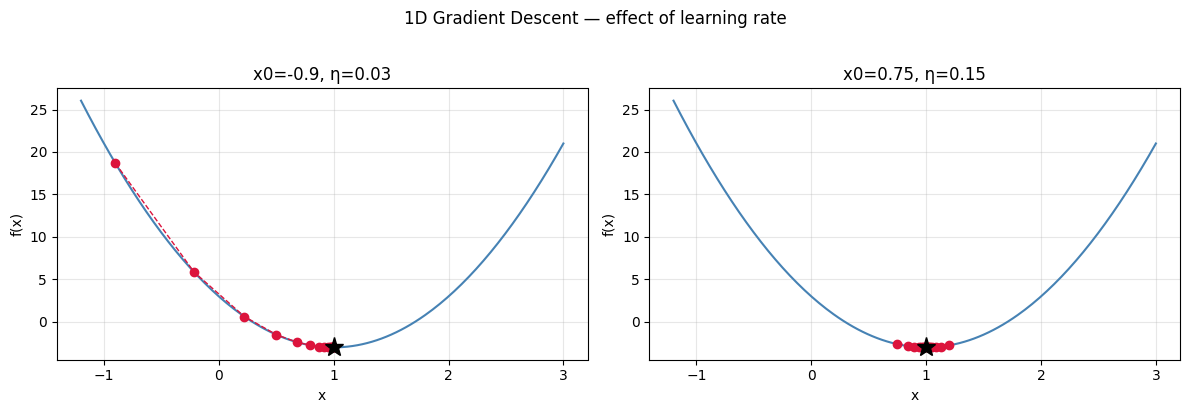

In [3]:
def f1d(x):
    return 6*x**2 - 12*x + 3

def df1d(x):
    return 12*x - 12

def run_gd_1d(x0, lr, n_steps=20):
    xs = [x0]
    x = x0
    for _ in range(n_steps):
        x = x - lr * df1d(x)
        xs.append(x)
    return np.array(xs)

xs_grid = np.linspace(-1.2, 3.0, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (x0, lr) in zip(axes, [(-0.9, 0.03), (0.75, 0.15)]):
    traj = run_gd_1d(x0, lr, n_steps=15)
    ax.plot(xs_grid, f1d(xs_grid), '-', color='steelblue', lw=1.5)
    ax.plot(traj, f1d(traj), 'o--', color='crimson', ms=6, lw=1)
    ax.plot(1, f1d(1), 'k*', ms=14)
    ax.set_title(f'x0={x0}, η={lr}'); ax.set_xlabel('x'); ax.set_ylabel('f(x)')
    ax.grid(alpha=0.3)
plt.suptitle('1D Gradient Descent — effect of learning rate', y=1.02)
plt.tight_layout(); plt.show()


**관찰**:
- 왼쪽 (η=0.03): 천천히 안정적으로 수렴
- 오른쪽 (η=0.15): 큰 step 으로 진동하며 수렴 — 너무 크면 발산 가능

학습률 하나가 학습 양상을 완전히 바꾼다.

---
## 예제 2: 2D 골짜기 — Ill-conditioned 함수

신경망에서 자주 일어나는 상황: **어떤 방향은 매우 가파르고, 다른 방향은 평탄**.
이걸 단순화한 예: $f(x,y) = 6x^2 + 40y^2 - 12x - 30y + 3$

y축 곡률이 x축의 약 7배 → 같은 η 를 쓰면 y 방향은 진동, x 방향은 천천히 진행.

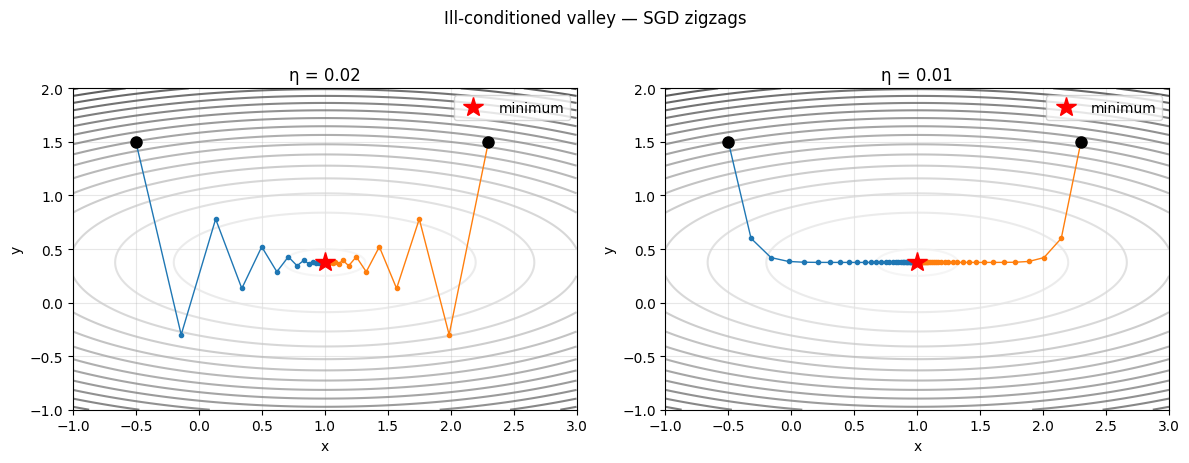

In [4]:
def f2d_valley(p):
    x, y = p[0], p[1]
    return 6*x**2 + 40*y**2 - 12*x - 30*y + 3

def df2d_valley(p):
    x, y = p[0], p[1]
    return np.array([12*x - 12, 80*y - 30])

def run_gd_2d(grad_fn, start, lr, n_steps=40):
    traj = [np.array(start, dtype=float)]
    p = np.array(start, dtype=float)
    for _ in range(n_steps):
        p = p - lr * grad_fn(p)
        traj.append(p.copy())
    return np.array(traj)

# 등고선
xx, yy = np.meshgrid(np.linspace(-1, 3, 200), np.linspace(-1, 2, 200))
zz = 6*xx**2 + 40*yy**2 - 12*xx - 30*yy + 3

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, lr in zip(axes, [0.02, 0.01]):
    ax.contour(xx, yy, zz, levels=20, cmap='gray_r', alpha=0.7)
    for start in [(-0.5, 1.5), (2.3, 1.5)]:
        traj = run_gd_2d(df2d_valley, start, lr, n_steps=40)
        ax.plot(traj[:, 0], traj[:, 1], 'o-', ms=3, lw=1)
        ax.plot(*start, 'ko', ms=8)
    ax.plot(1.0, 0.375, 'r*', ms=15, label='minimum')
    ax.set_title(f'η = {lr}'); ax.legend(loc='upper right')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.grid(alpha=0.3)
plt.suptitle('Ill-conditioned valley — SGD zigzags', y=1.02)
plt.tight_layout(); plt.show()


**관찰**:
- η=0.02 (왼쪽): y축에서 심하게 진동 (overshoot) — 그러나 x축은 빨리 진행
- η=0.01 (오른쪽): 진동은 줄지만, x축 수렴이 너무 느림

**딜레마**: 큰 η는 진동, 작은 η는 느림. SGD 단독으로는 양립 불가.

→ Momentum과 RMSProp이 이 문제를 각각 다른 방식으로 푼다.

---
## 예제 3: Local minimum 함정

봉우리가 2개인 손실 표면. SGD는 출발점에 따라 더 얕은 극소점에 갇힌다.

$f(x,y) = -2\exp(-\frac{1}{2}((x+1)^2 + (y-1)^2)) - \exp(-\frac{1}{2}((x-1)^2 + (y+1)^2))$

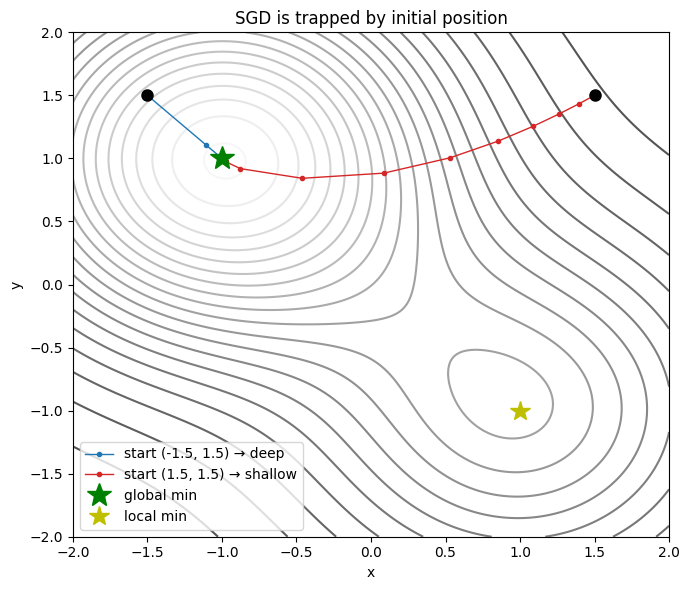

In [5]:
def f2d_multi(p):
    x, y = p[0], p[1]
    g1 = np.exp(-0.5*((x+1)**2 + (y-1)**2))
    g2 = np.exp(-0.5*((x-1)**2 + (y+1)**2))
    return -2*g1 - g2

def df2d_multi(p):
    x, y = p[0], p[1]
    g1 = np.exp(-0.5*((x+1)**2 + (y-1)**2))
    g2 = np.exp(-0.5*((x-1)**2 + (y+1)**2))
    dx = 2*(x+1)*g1 + (x-1)*g2
    dy = 2*(y-1)*g1 + (y+1)*g2
    return np.array([dx, dy])

xx, yy = np.meshgrid(np.linspace(-2, 2, 200), np.linspace(-2, 2, 200))
zz = np.zeros_like(xx)
for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        zz[i, j] = f2d_multi([xx[i, j], yy[i, j]])

fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(xx, yy, zz, levels=20, cmap='gray_r', alpha=0.7)

# 두 출발점: 하나는 깊은 골로, 하나는 얕은 골에 빠진다
for start, color, label in [((-1.5, 1.5), 'tab:blue', 'start (-1.5, 1.5) → deep'),
                             ((1.5, 1.5), 'tab:red',  'start (1.5, 1.5) → shallow')]:
    traj = run_gd_2d(df2d_multi, start, 0.5, n_steps=50)
    ax.plot(traj[:, 0], traj[:, 1], 'o-', ms=3, lw=1, color=color, label=label)
    ax.plot(*start, 'ko', ms=8)

ax.plot(-1, 1, 'g*', ms=18, label='global min')
ax.plot(1, -1, 'y*', ms=15, label='local min')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend(loc='lower left')
ax.set_title('SGD is trapped by initial position')
plt.tight_layout(); plt.show()


**관찰**: 빨간색 궤적은 더 얕은 local minimum에 빠짐. SGD는 출발점에 종속.

미니배치 SGD의 잡음(noise)이 local minimum 탈출에 도움을 주기도 하지만,
**Momentum** 처럼 이전 방향의 관성을 더하면 작은 봉우리는 넘어갈 수도 있다.

---
## 예제 4: Optimizer 4종 궤적 비교 (Ill-conditioned valley)

같은 함수 ($f(x,y) = 6x^2 + 40y^2 - 12x - 30y + 3$), 같은 출발점에서 4가지 optimizer 의 궤적.

각 optimizer 의 update 규칙을 손으로 직접 구현해서 보여준다 — `neural_network.py` 의 클래스들과 동일한 수식.

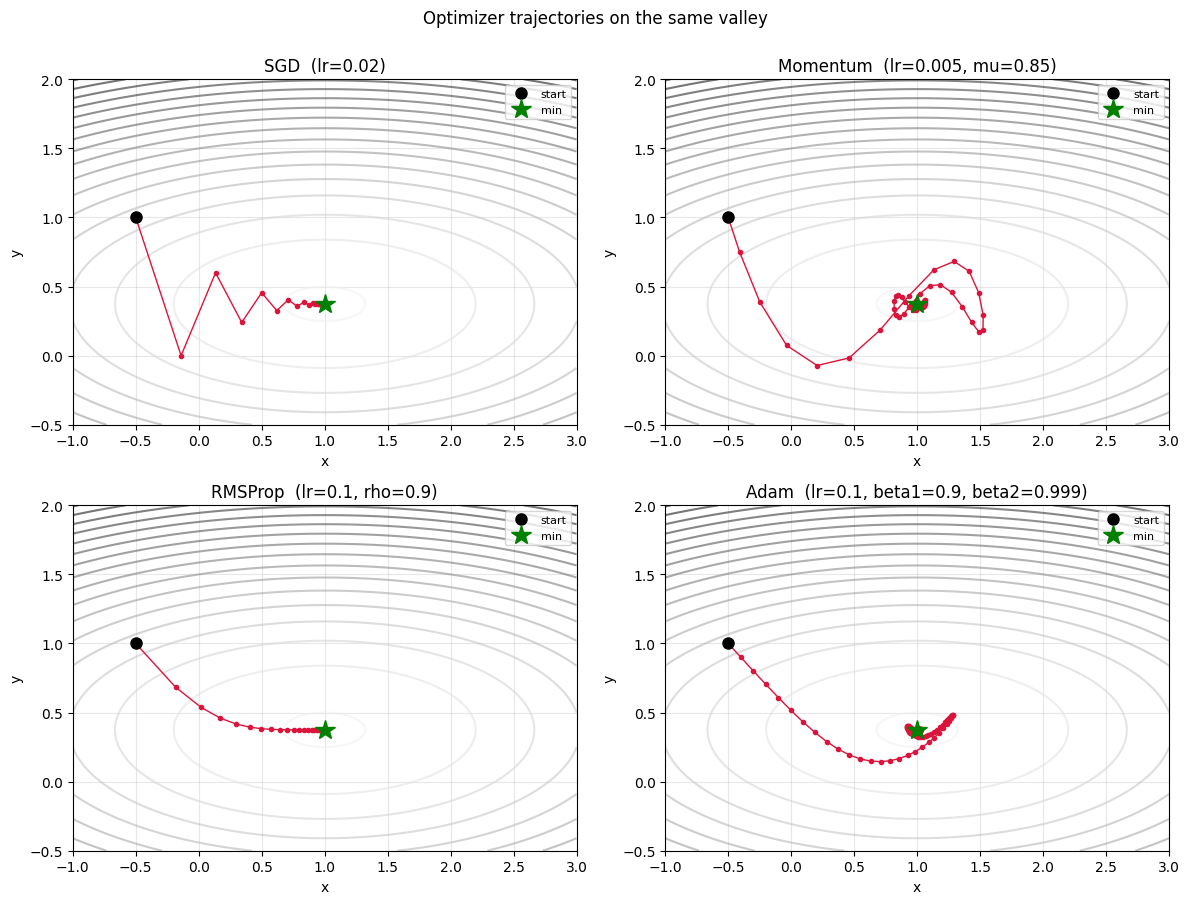

In [6]:
def run_optimizer_2d(opt_name, grad_fn, start, n_steps=60,
                     lr=0.02, mu=0.9, rho=0.9,
                     beta1=0.9, beta2=0.999, eps=1e-8):
    """2D 함수에서 4종 optimizer 의 궤적을 손으로 시뮬레이션."""
    p = np.array(start, dtype=float)
    v = np.zeros_like(p)         # momentum velocity / adam 1st
    s = np.zeros_like(p)         # rmsprop / adam 2nd
    traj = [p.copy()]
    for t in range(1, n_steps + 1):
        g = grad_fn(p)
        if opt_name == 'SGD':
            p = p - lr * g
        elif opt_name == 'Momentum':
            v = mu * v - lr * g
            p = p + v
        elif opt_name == 'RMSProp':
            s = rho * s + (1 - rho) * g**2
            p = p - lr * g / (np.sqrt(s) + eps)
        elif opt_name == 'Adam':
            v = beta1 * v + (1 - beta1) * g
            s = beta2 * s + (1 - beta2) * g**2
            v_hat = v / (1 - beta1**t)
            s_hat = s / (1 - beta2**t)
            p = p - lr * v_hat / (np.sqrt(s_hat) + eps)
        traj.append(p.copy())
    return np.array(traj)

# 같은 골짜기 함수
xx, yy = np.meshgrid(np.linspace(-1, 3, 200), np.linspace(-0.5, 2, 200))
zz = 6*xx**2 + 40*yy**2 - 12*xx - 30*yy + 3

start = (-0.5, 1.0)

# 각 optimizer 에 비슷한 step 크기를 주기 위해 lr 별도 튜닝
configs = [
    ('SGD',      dict(lr=0.02)),
    ('Momentum', dict(lr=0.005, mu=0.85)),
    ('RMSProp',  dict(lr=0.1,   rho=0.9)),
    ('Adam',     dict(lr=0.1,   beta1=0.9, beta2=0.999)),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (name, kw) in zip(axes.flat, configs):
    traj = run_optimizer_2d(name, df2d_valley, start, n_steps=80, **kw)
    ax.contour(xx, yy, zz, levels=20, cmap='gray_r', alpha=0.6)
    ax.plot(traj[:, 0], traj[:, 1], 'o-', ms=3, lw=1, color='crimson')
    ax.plot(*start, 'ko', ms=8, label='start')
    ax.plot(1.0, 0.375, 'g*', ms=15, label='min')
    kw_str = ', '.join(f'{k}={v}' for k, v in kw.items())
    ax.set_title(f'{name}  ({kw_str})')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)
plt.suptitle('Optimizer trajectories on the same valley', y=1.0)
plt.tight_layout(); plt.show()


**관찰 포인트**:

| Optimizer | 핵심 동작 | 그림에서 보이는 것 |
|-----------|----------|------------------|
| **SGD** | 매 step 에 같은 lr 적용 | y축 진동 (overshoot), x축 천천히 |
| **Momentum** | 이전 velocity 누적 | 진동이 줄고 골짜기를 따라 흐름 |
| **RMSProp** | 차원별 g² 누적으로 lr 자동 조정 | 가파른 y축 step 자동 감소 → 진동 적음 |
| **Adam** | Momentum + RMSProp | 두 효과 모두 — 가장 안정적 |

수식만 봐선 모르지만 그림으로 보면 **왜** Adam이 기본 선택지가 되었는지 명확하다.

---
## 예제 5: Local minimum 에서 Momentum 의 효과

운동량(관성)이 작은 봉우리를 넘는 데 도움이 될까? — 두 봉우리 함수에서 같은 출발점.

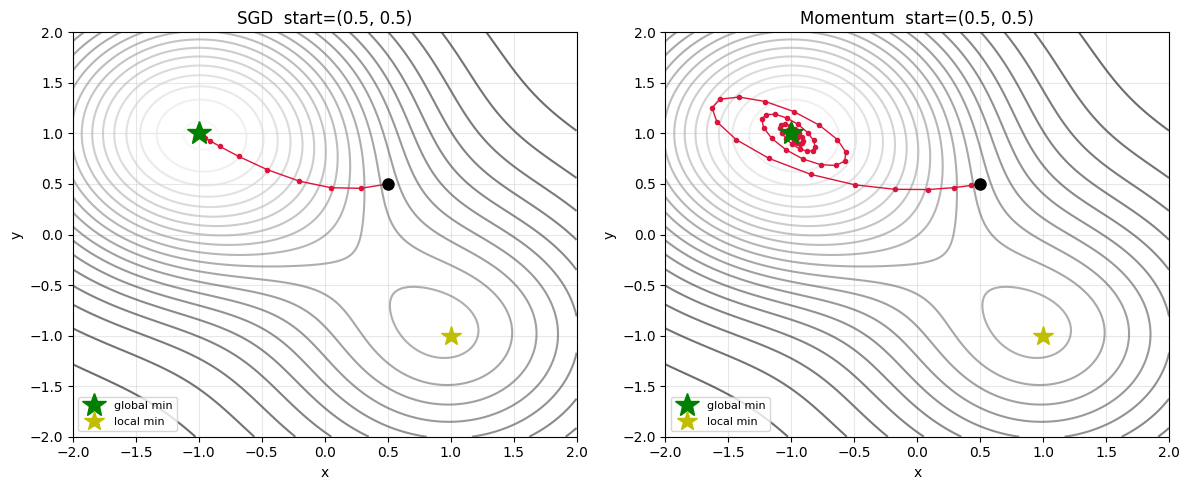

In [7]:
# 얕은 골에 빠지기 쉬운 출발점에서 SGD vs Momentum
xx, yy = np.meshgrid(np.linspace(-2, 2, 200), np.linspace(-2, 2, 200))
zz = np.zeros_like(xx)
for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        zz[i, j] = f2d_multi([xx[i, j], yy[i, j]])

start = (0.5, 0.5)   # 두 봉우리 경계 근처

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, kw) in zip(axes, [('SGD', dict(lr=0.3)),
                                   ('Momentum', dict(lr=0.1, mu=0.9))]):
    traj = run_optimizer_2d(name, df2d_multi, start, n_steps=60, **kw)
    ax.contour(xx, yy, zz, levels=20, cmap='gray_r', alpha=0.6)
    ax.plot(traj[:, 0], traj[:, 1], 'o-', ms=3, lw=1, color='crimson')
    ax.plot(*start, 'ko', ms=8)
    ax.plot(-1, 1, 'g*', ms=18, label='global min')
    ax.plot(1, -1, 'y*', ms=15, label='local min')
    ax.set_title(f'{name}  start={start}'); ax.legend(loc='lower left', fontsize=8)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**관찰**: 같은 출발점에서 Momentum 은 관성으로 봉우리를 더 잘 넘는다.
단, 항상 도움이 되는 것은 아님 — 강한 운동량이 오히려 global min 을 지나쳐버릴 수도 있음.

(이 예제는 결정론적이라 효과가 제한적이지만, 신경망의 미니배치 잡음과 결합되면 강력해진다.)

---
## 예제 6: 신경망에서의 비교 — Iris 분류

이제 실제 신경망에서 optimizer 4종을 같은 네트워크·같은 epoch 수로 비교한다.

**중요**: 같은 데이터·같은 초기화로 시작해야 공정한 비교가 된다.

In [8]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = StandardScaler().fit_transform(iris.data)
Y = np.eye(3)[iris.target]
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=1, stratify=iris.target)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (105, 4), Test: (45, 4)


In [9]:
def make_iris_net():
    """매번 같은 초기 가중치를 갖는 네트워크."""
    np.random.seed(0)
    net = Network()
    net.add(Dense(4, 16))
    net.add(ReLU())
    net.add(Dense(16, 3))
    return net

configs = [
    ('SGD',      SGD,      dict(lr=0.05)),
    ('Momentum', Momentum, dict(lr=0.01, mu=0.9)),
    ('RMSProp',  RMSProp,  dict(lr=0.005)),
    ('Adam',     Adam,     dict(lr=0.01)),
]

results = {}
for name, OptCls, kw in configs:
    np.random.seed(0)
    net = make_iris_net()
    loss_fn = SoftmaxCE()
    opt = OptCls(**kw)
    history = fit(net, X_train, Y_train, loss_fn, opt,
                  epochs=100, batch_size=16, verbose=False)
    test_acc = (net.forward(X_test).argmax(1) == Y_test.argmax(1)).mean()
    results[name] = (history['loss'], test_acc)
    print(f"{name:9s}  final loss={history['loss'][-1]:.4f}  test_acc={test_acc:.1%}")


SGD        final loss=0.0845  test_acc=97.8%
Momentum   final loss=0.0577  test_acc=97.8%
RMSProp    final loss=0.0515  test_acc=97.8%
Adam       final loss=0.0408  test_acc=97.8%


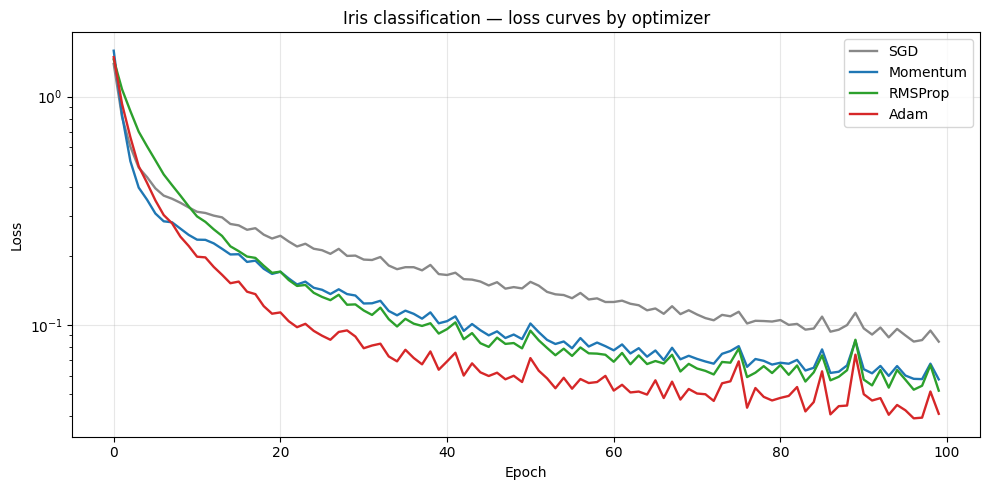

In [10]:
# 학습 곡선 비교
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'SGD': '#888', 'Momentum': '#1f77b4', 'RMSProp': '#2ca02c', 'Adam': '#d62728'}
for name, (losses, _) in results.items():
    ax.plot(losses, label=name, color=colors[name], lw=1.7)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_yscale('log'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Iris classification — loss curves by optimizer')
plt.tight_layout(); plt.show()


**관찰**:
- **Adam / Momentum / RMSProp** 모두 SGD 보다 빠르고 깊게 수렴
- 최종 정확도는 비슷 (Iris 는 충분히 쉬운 문제) — 차이는 **수렴 속도**

→ 더 어려운 문제(MNIST 같은)에서 차이가 더 뚜렷해진다. **이 검증은 숙제에서 직접 해보시오.**

---
## 정리

| Optimizer | 핵심 아이디어 | 강점 | 약점 |
|-----------|--------------|------|------|
| **SGD** | θ ← θ − η·g | 단순, 메모리 적음 | 진동, 느림, lr 민감 |
| **Momentum** | 이전 velocity 누적 | 진동 감소, 골짜기 통과 | lr 민감 |
| **RMSProp** | 차원별 g² 추적 → lr 자동 조정 | 평탄/가파른 방향 자동 처리 | momentum 효과 없음 |
| **Adam** | Momentum + RMSProp | 두 효과 모두, lr 둔감 | 메모리 2배 |

**실전 가이드**:
1. **첫 시도는 Adam (lr=1e-3)** — 거의 항상 무난한 성능
2. 더 짜내야 하면: **SGD + Momentum + lr scheduling** (이미지 분류 SOTA 들이 자주 쓰는 조합)
3. 메모리가 빠듯하면: SGD/Momentum
